## Exploratory Data Analysis

- Data source: https://www.kaggle.com/datasets/tunguz/bank-marketing-data-set
- Artigo: https://sci-hub.box/10.1016/j.dss.2014.03.001

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from utils_eda import column_descriptions, miss_cat_pd, cont_perc_categorias, grafico_barras

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

%matplotlib inline

### Data

In [4]:
df1 = pd.read_csv('data/bank-marketing-data-set/bank-additional-full.csv', sep = ';')
df2 = pd.read_csv('data/bank-marketing-data-set/bank-full.csv', sep = ';')

print(f"Tamanho do dataset 1 (dados de maio/2008 a novembro/2010): {df1.shape}")
print(f"Tamanho do dataset 2 (versão mais antiga do dataset):      {df2.shape}")

Tamanho do dataset 1 (dados de maio/2008 a novembro/2010): (41188, 21)
Tamanho do dataset 2 (versão mais antiga do dataset):      (45211, 17)


In [5]:
df1.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Nulls e número de categorias

In [21]:
df_cats = miss_cat_pd(df1).rename(columns = {'perc_missings':'perc_missings_df1', 'n_categorias':'n_categorias_df1'})\
    .merge(miss_cat_pd(df2).rename(columns = {'perc_missings':'perc_missings_df2', 'n_categorias':'n_categorias_df2'}),
           on = ['coluna'], how = 'outer')

df_cats['description'] = df_cats['coluna'].map(column_descriptions)

with pd.option_context('display.max_colwidth', None):
    display(df_cats[['coluna', 'description', 'perc_missings_df1', 'perc_missings_df2', 'n_categorias_df1', 'n_categorias_df2']].sort_values('n_categorias_df2'))


,coluna,description,perc_missings_df1,perc_missings_df2,n_categorias_df1,n_categorias_df2
13,housing,Has housing loan,0.0,0.0,3.0,2.0
15,loan,Has personal loan,0.0,0.0,3.0,2.0
8,default,Has credit in default,0.0,0.0,3.0,2.0
22,y,Whether the client subscribed to a term deposit,0.0,0.0,2.0,2.0
16,marital,Marital status,0.0,0.0,4.0,3.0
5,contact,Contact communication type,0.0,0.0,2.0,3.0
10,education,Education level,0.0,0.0,8.0,4.0
20,poutcome,Outcome of the previous marketing campaign,0.0,0.0,3.0,4.0
14,job,Type of job,0.0,0.0,12.0,12.0
17,month,Last contact month of year,0.0,0.0,10.0,12.0


## Distribuições

### Age

In [26]:
display(df1[['age']].describe(percentiles = [i/10 for i in range(10)]).T)

,count,mean,std,min,0%,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
age,41188.0,40.02406,10.42125,17.0,17.0,28.0,31.0,33.0,35.0,38.0,41.0,45.0,49.0,55.0,98.0


In [5]:
fig = px.histogram(df1, x = 'age', marginal = 'box')
fig.show()

### Job

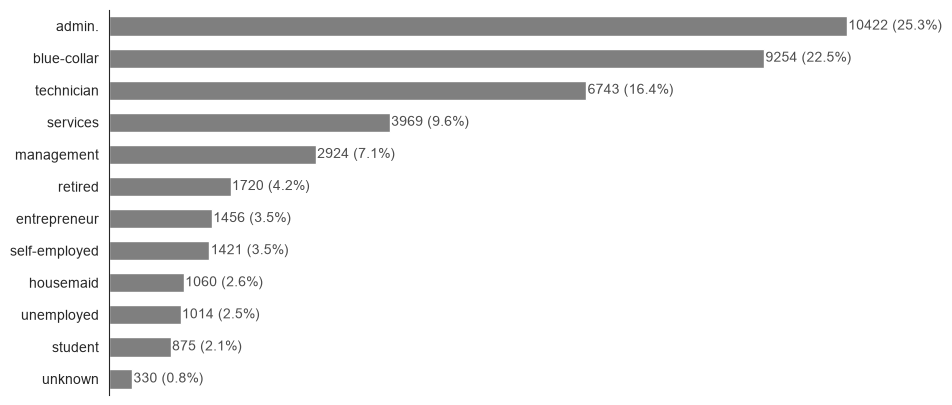

In [9]:
grafico_barras(df_ = df1, coluna = 'job', figsize = (10, 5), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Marital

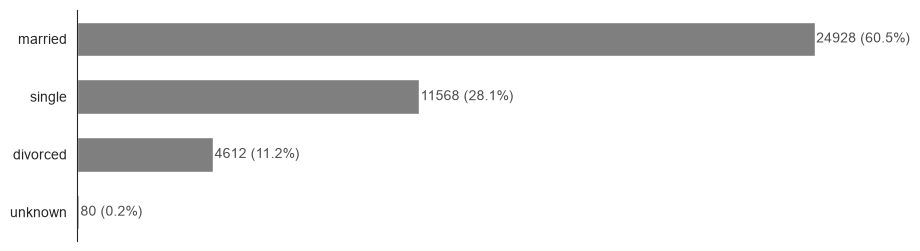

In [11]:
grafico_barras(df_ = df1, coluna = 'marital', figsize = (10, 3), sort_categorias = False, casas_decimais = 1, espessura_barras = 0.6)

### Education

In [12]:
df1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Default (se tem crédito como padrão)

### Housing (se)